# Metode Estimasi Statistik
## Dataset: Healthcare Dataset

Notebook ini membahas berbagai **metode estimasi statistik** menggunakan dataset kesehatan, meliputi:

1. Estimasi Titik (Point Estimation)
2. Estimasi Interval (Interval Estimation / Confidence Interval)
3. Estimasi Maximum Likelihood (MLE)
4. Estimasi Metode Momen (Method of Moments)
5. Estimasi Bootstrap
6. Estimasi Bayesian (Prior & Posterior)
7. Estimasi Regresi Linier
8. Estimasi Proporsi

---
## 0. Import Library & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Style plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Load dataset
df = pd.read_csv('healthcare_dataset.csv')

# Preprocessing dasar
df.columns = df.columns.str.strip()
df['Name'] = df['Name'].str.title()
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

print('Shape dataset:', df.shape)
df.head()

Shape dataset: (55500, 16)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [2]:
print('Info Dataset:')
df.info()
print('\nStatistik Deskriptif:')
df[['Age', 'Billing Amount', 'Length of Stay']].describe().round(3)

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-nu

,Age,Billing Amount,Length of Stay
count,55500.000,55500.000,55500.000
mean,51.539,25539.316,15.509
std,19.602,14211.454,8.660
min,13.000,-2008.492,1.000
25%,35.000,13241.225,8.000
50%,52.000,25538.069,15.000
75%,68.000,37820.508,23.000
max,89.000,52764.277,30.000


---
## 1. Estimasi Titik (Point Estimation)

Estimasi titik menghasilkan **satu nilai tunggal** sebagai taksiran parameter populasi.

Estimator yang umum digunakan:
- **Mean (Rata-rata)** → estimator parameter μ
- **Median** → estimator lokasi yang robust
- **Varians & Standar Deviasi** → estimator parameter σ²
- **Proporsi sampel** → estimator parameter p

In [3]:
# ============================================================
# ESTIMASI TITIK - Billing Amount
# ============================================================
x = df['Billing Amount'].dropna()

n    = len(x)
mean = np.mean(x)
med  = np.median(x)
var  = np.var(x, ddof=1)          # varians tidak bias (S²)
std  = np.std(x, ddof=1)          # standar deviasi tidak bias (S)
se   = std / np.sqrt(n)           # standard error

print('===== ESTIMASI TITIK: Billing Amount =====')
print(f'Ukuran sampel (n)       : {n:,}')
print(f'Mean (x̄)               : Rp {mean:,.2f}')
print(f'Median                  : Rp {med:,.2f}')
print(f'Varians (S²)            : {var:,.2f}')
print(f'Std Deviasi (S)         : {std:,.2f}')
print(f'Standard Error (SE)     : {se:,.4f}')

# Estimasi titik per kondisi medis
print('\n===== ESTIMASI TITIK per Kondisi Medis =====')
summary = df.groupby('Medical Condition')['Billing Amount'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std'
).round(2)
print(summary)

===== ESTIMASI TITIK: Billing Amount =====
Ukuran sampel (n)       : 55,500
Mean (x̄)               : Rp 25,539.32
Median                  : Rp 25,538.07
Varians (S²)            : 201,965,437.04
Std Deviasi (S)         : 14,211.45
Standard Error (SE)     : 60.3243

===== ESTIMASI TITIK per Kondisi Medis =====
                      n      mean    median       std
Medical Condition                                    
Arthritis          9308  25497.33  25581.76  14276.53
Asthma             9185  25635.25  25661.87  14241.68
Cancer             9227  25161.79  24910.98  14200.27
Diabetes           9304  25638.41  25621.08  14159.52
Hypertension       9245  25497.10  25275.67  14305.40
Obesity            9231  25805.97  26130.00  14079.53


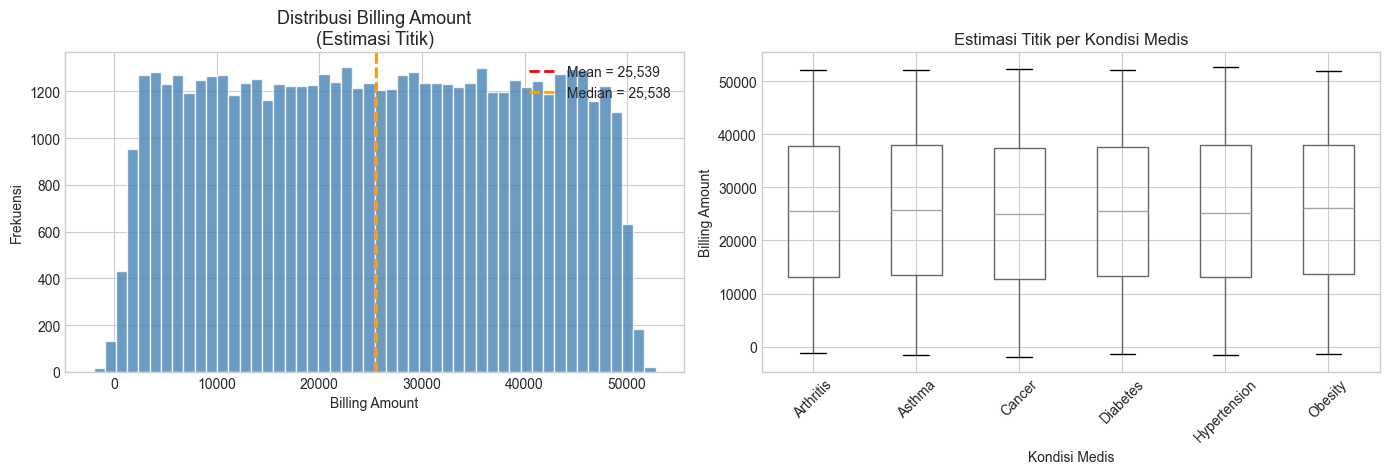

In [4]:
# Visualisasi distribusi & estimasi titik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dengan mean & median
axes[0].hist(x, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(mean, color='red',    linestyle='--', linewidth=2, label=f'Mean = {mean:,.0f}')
axes[0].axvline(med,  color='orange', linestyle='--', linewidth=2, label=f'Median = {med:,.0f}')
axes[0].set_title('Distribusi Billing Amount\n(Estimasi Titik)', fontsize=13)
axes[0].set_xlabel('Billing Amount')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot per kondisi medis
df.boxplot(column='Billing Amount', by='Medical Condition', ax=axes[1], rot=45)
axes[1].set_title('Estimasi Titik per Kondisi Medis')
axes[1].set_xlabel('Kondisi Medis')
axes[1].set_ylabel('Billing Amount')
plt.suptitle('')

plt.tight_layout()
plt.show()

---
## 2. Estimasi Interval (Confidence Interval)

Estimasi interval memberikan **rentang nilai** yang dipercaya memuat parameter populasi dengan tingkat kepercayaan tertentu (misalnya 95%).

$$\text{CI} = \bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

Untuk sampel besar (n > 30), gunakan distribusi **Z**. Untuk sampel kecil, gunakan distribusi **t**.

In [5]:
# ============================================================
# CONFIDENCE INTERVAL - Billing Amount
# ============================================================
x = df['Billing Amount'].dropna()

for conf in [0.90, 0.95, 0.99]:
    ci = stats.t.interval(conf, df=len(x)-1, loc=np.mean(x), scale=stats.sem(x))
    print(f'CI {int(conf*100)}%: [{ci[0]:,.2f}, {ci[1]:,.2f}]  | Lebar = {ci[1]-ci[0]:,.2f}')

CI 90%: [25,440.09, 25,638.54]  | Lebar = 198.45
CI 95%: [25,421.08, 25,657.55]  | Lebar = 236.47
CI 99%: [25,383.93, 25,694.71]  | Lebar = 310.78


In [6]:
# CI per kondisi medis (95%)
print('===== CI 95% Billing Amount per Kondisi Medis =====')
results = []
for cond, grp in df.groupby('Medical Condition'):
    vals = grp['Billing Amount'].dropna()
    ci = stats.t.interval(0.95, df=len(vals)-1, loc=np.mean(vals), scale=stats.sem(vals))
    results.append({'Kondisi': cond, 'n': len(vals), 'Mean': np.mean(vals),
                    'CI Lower': ci[0], 'CI Upper': ci[1], 'Lebar CI': ci[1]-ci[0]})

ci_df = pd.DataFrame(results).set_index('Kondisi').round(2)
print(ci_df)

# CI untuk variabel Age
age_ci = stats.t.interval(0.95, df=len(df['Age'])-1,
                           loc=df['Age'].mean(), scale=stats.sem(df['Age']))
print(f'\nCI 95% Usia: [{age_ci[0]:.2f}, {age_ci[1]:.2f}] tahun')

===== CI 95% Billing Amount per Kondisi Medis =====
                 n      Mean  CI Lower  CI Upper  Lebar CI
Kondisi                                                   
Arthritis     9308  25497.33  25207.26  25787.39    580.13
Asthma        9185  25635.25  25343.96  25926.54    582.58
Cancer        9227  25161.79  24872.01  25451.57    579.56
Diabetes      9304  25638.41  25350.65  25926.16    575.50
Hypertension  9245  25497.10  25205.45  25788.74    583.29
Obesity       9231  25805.97  25518.72  26093.23    574.51

CI 95% Usia: [51.38, 51.70] tahun


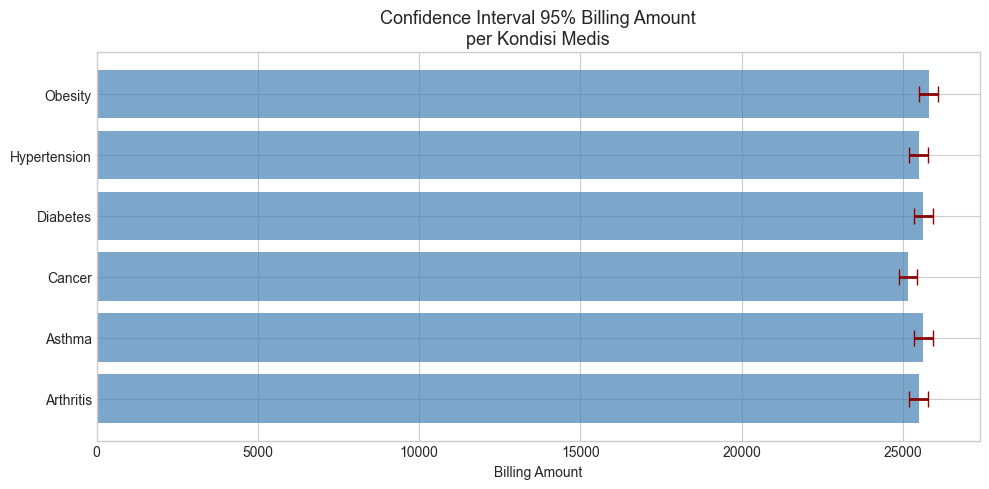

In [7]:
# Visualisasi CI per kondisi medis
fig, ax = plt.subplots(figsize=(10, 5))

means  = ci_df['Mean'].values
lowers = means - ci_df['CI Lower'].values
uppers = ci_df['CI Upper'].values - means
labels = ci_df.index.tolist()

ax.barh(labels, means, xerr=[lowers, uppers], color='steelblue',
        error_kw={'elinewidth': 2, 'capsize': 6, 'ecolor': 'darkred'}, alpha=0.7)
ax.set_xlabel('Billing Amount')
ax.set_title('Confidence Interval 95% Billing Amount\nper Kondisi Medis', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Estimasi Maximum Likelihood (MLE)

MLE mencari nilai parameter θ yang **memaksimalkan fungsi likelihood** L(θ|data), yaitu probabilitas mengamati data yang ada jika parameter bernilai θ.

$$\hat{\theta}_{MLE} = \arg\max_\theta \log L(\theta | x_1, ..., x_n)$$

Untuk distribusi Normal:
$$\hat{\mu}_{MLE} = \bar{x}, \quad \hat{\sigma}^2_{MLE} = \frac{1}{n}\sum(x_i - \bar{x})^2$$

In [8]:
# ============================================================
# MLE - Asumsi Normal pada Billing Amount & Age
# ============================================================
for col in ['Billing Amount', 'Age', 'Length of Stay']:
    data = df[col].dropna().values
    mu_mle, std_mle = stats.norm.fit(data)   # MLE untuk distribusi Normal
    print(f'MLE {col}:  μ_hat = {mu_mle:.4f},  σ_hat = {std_mle:.4f}')

print()

# MLE manual dengan scipy.optimize (Billing Amount)
data = df['Billing Amount'].dropna().values

def neg_log_likelihood(params, data):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    ll = -np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))
    return ll

result = minimize(neg_log_likelihood, x0=[np.mean(data), np.std(data)],
                  args=(data,), method='Nelder-Mead')

mu_opt, sigma_opt = result.x
print('===== MLE Manual (Optimisasi Numerik) =====')
print(f'μ_MLE   = {mu_opt:.4f}')
print(f'σ_MLE   = {sigma_opt:.4f}')
print(f'Log-Likelihood = {-result.fun:.4f}')

MLE Billing Amount:  μ_hat = 25539.3161,  σ_hat = 14211.3264
MLE Age:  μ_hat = 51.5395,  σ_hat = 19.6023
MLE Length of Stay:  μ_hat = 15.5090,  σ_hat = 8.6595

===== MLE Manual (Optimisasi Numerik) =====
μ_MLE   = 25539.3161
σ_MLE   = 14211.3264
Log-Likelihood = -609430.6866


In [9]:
# Uji goodness-of-fit distribusi
print('===== Uji Normalitas (Kolmogorov-Smirnov) =====')
for col in ['Age', 'Billing Amount', 'Length of Stay']:
    data = df[col].dropna().values
    mu_mle, std_mle = stats.norm.fit(data)
    ks_stat, p_val = stats.kstest(data, 'norm', args=(mu_mle, std_mle))
    print(f'{col:20s}: KS={ks_stat:.4f}, p={p_val:.4f}  →  {'Normal ✓' if p_val>0.05 else 'Tidak Normal ✗'}')

===== Uji Normalitas (Kolmogorov-Smirnov) =====
Age                 : KS=0.0636, p=0.0000  →  Tidak Normal ✗
Billing Amount      : KS=0.0577, p=0.0000  →  Tidak Normal ✗
Length of Stay      : KS=0.0744, p=0.0000  →  Tidak Normal ✗


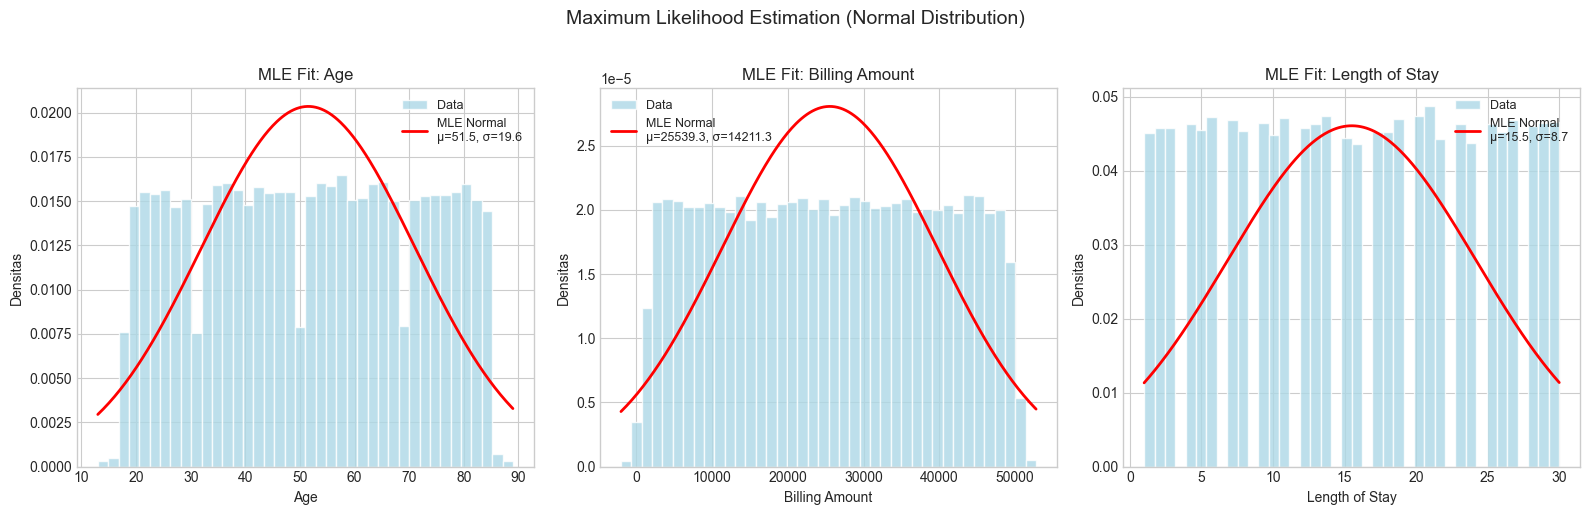

In [10]:
# Visualisasi MLE fit
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Age', 'Billing Amount', 'Length of Stay']):
    data = df[col].dropna().values
    mu_f, std_f = stats.norm.fit(data)
    xmin, xmax = data.min(), data.max()
    xs = np.linspace(xmin, xmax, 300)
    ax.hist(data, bins=40, density=True, color='lightblue', edgecolor='white', alpha=0.8, label='Data')
    ax.plot(xs, stats.norm.pdf(xs, mu_f, std_f), 'r-', lw=2, label=f'MLE Normal\nμ={mu_f:.1f}, σ={std_f:.1f}')
    ax.set_title(f'MLE Fit: {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=9)

plt.suptitle('Maximum Likelihood Estimation (Normal Distribution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Estimasi Metode Momen (Method of Moments)

Metode Momen menyamakan **momen populasi** dengan **momen sampel** untuk mendapatkan estimator parameter.

Untuk distribusi Normal:
- Momen ke-1: $E[X] = \mu \Rightarrow \hat{\mu} = \bar{x}$
- Momen ke-2: $E[X^2] = \mu^2 + \sigma^2 \Rightarrow \hat{\sigma}^2 = \bar{x^2} - \bar{x}^2$

Untuk distribusi Gamma ($\alpha, \beta$):
- $\hat{\alpha} = \bar{x}^2 / S^2$, $\hat{\beta} = S^2 / \bar{x}$

In [11]:
# ============================================================
# METODE MOMEN - Billing Amount
# ============================================================
data = df['Billing Amount'].dropna().values

# Momen sampel
m1 = np.mean(data)             # momen ke-1 (mean)
m2 = np.mean(data**2)          # momen ke-2
m3 = np.mean(data**3)          # momen ke-3

# Estimator MM untuk distribusi Normal
mu_mm    = m1
sigma_mm = np.sqrt(m2 - m1**2)

print('===== METODE MOMEN: Billing Amount =====')
print(f'Momen ke-1 (m1) = {m1:.4f}')
print(f'Momen ke-2 (m2) = {m2:.4f}')
print(f'μ_MM   = {mu_mm:.4f}')
print(f'σ_MM   = {sigma_mm:.4f}')

# Estimator MM untuk distribusi Gamma (Billing Amount)
S2 = np.var(data, ddof=1)
alpha_mm = (m1**2) / S2
beta_mm  = S2 / m1
print(f'\nGamma MM:  α_hat = {alpha_mm:.4f},  β_hat = {beta_mm:.4f}')

# Perbandingan MM vs MLE
mu_mle, std_mle = stats.norm.fit(data)
print('\n===== Perbandingan MLE vs Metode Momen =====')
print(f'{'Metode':<15} {'μ':>12} {'σ':>12}')
print('-' * 40)
print(f'{'MLE':<15} {mu_mle:>12.4f} {std_mle:>12.4f}')
print(f'{'Momen':<15} {mu_mm:>12.4f} {sigma_mm:>12.4f}')

===== METODE MOMEN: Billing Amount =====
Momen ke-1 (m1) = 25539.3161
Momen ke-2 (m2) = 854218464.7370
μ_MM   = 25539.3161
σ_MM   = 14211.3264

Gamma MM:  α_hat = 3.2295,  β_hat = 7908.0206

===== Perbandingan MLE vs Metode Momen =====
Metode                     μ            σ
----------------------------------------
MLE               25539.3161   14211.3264
Momen             25539.3161   14211.3264


In [12]:
# Momen standar: skewness & kurtosis
print('===== Momen Standar per Variabel =====')
for col in ['Age', 'Billing Amount', 'Length of Stay']:
    d = df[col].dropna().values
    print(f'{col}:')
    print(f'  Skewness  = {stats.skew(d):.4f}')
    print(f'  Kurtosis  = {stats.kurtosis(d):.4f}  (excess)')

===== Momen Standar per Variabel =====
Age:
  Skewness  = -0.0057
  Kurtosis  = -1.1856  (excess)
Billing Amount:
  Skewness  = -0.0010
  Kurtosis  = -1.1906  (excess)
Length of Stay:
  Skewness  = 0.0019
  Kurtosis  = -1.2051  (excess)


---
## 5. Estimasi Bootstrap

Bootstrap adalah metode **resampling** — mengambil banyak sampel dengan penggantian dari data asli untuk mengestimasi distribusi sampling dari suatu statistik tanpa asumsi distribusi.

Langkah:
1. Ambil B sampel bootstrap (dengan replacement) dari data
2. Hitung statistik (misal: mean) untuk setiap sampel bootstrap
3. Gunakan distribusi empiris untuk estimasi & CI

In [13]:
# ============================================================
# BOOTSTRAP - Billing Amount
# ============================================================
np.random.seed(42)
data  = df['Billing Amount'].dropna().values
B     = 10_000   # jumlah bootstrap replications
n     = len(data)

boot_means    = np.empty(B)
boot_medians  = np.empty(B)
boot_stds     = np.empty(B)

for i in range(B):
    sample           = np.random.choice(data, size=n, replace=True)
    boot_means[i]    = np.mean(sample)
    boot_medians[i]  = np.median(sample)
    boot_stds[i]     = np.std(sample, ddof=1)

# CI Bootstrap Percentile 95%
ci_mean   = np.percentile(boot_means,   [2.5, 97.5])
ci_median = np.percentile(boot_medians, [2.5, 97.5])
ci_std    = np.percentile(boot_stds,    [2.5, 97.5])

print(f'===== BOOTSTRAP (B={B:,}) =====')
print(f'Estimasi Mean      : {boot_means.mean():,.2f}   CI 95%: [{ci_mean[0]:,.2f}, {ci_mean[1]:,.2f}]')
print(f'Estimasi Median    : {boot_medians.mean():,.2f}   CI 95%: [{ci_median[0]:,.2f}, {ci_median[1]:,.2f}]')
print(f'Estimasi Std Dev   : {boot_stds.mean():,.2f}   CI 95%: [{ci_std[0]:,.2f}, {ci_std[1]:,.2f}]')
print(f'Bootstrap SE (mean): {boot_means.std():,.4f}')

===== BOOTSTRAP (B=10,000) =====
Estimasi Mean      : 25,539.35   CI 95%: [25,423.09, 25,658.83]
Estimasi Median    : 25,536.49   CI 95%: [25,309.17, 25,743.10]
Estimasi Std Dev   : 14,211.44   CI 95%: [14,158.56, 14,265.11]
Bootstrap SE (mean): 60.4350


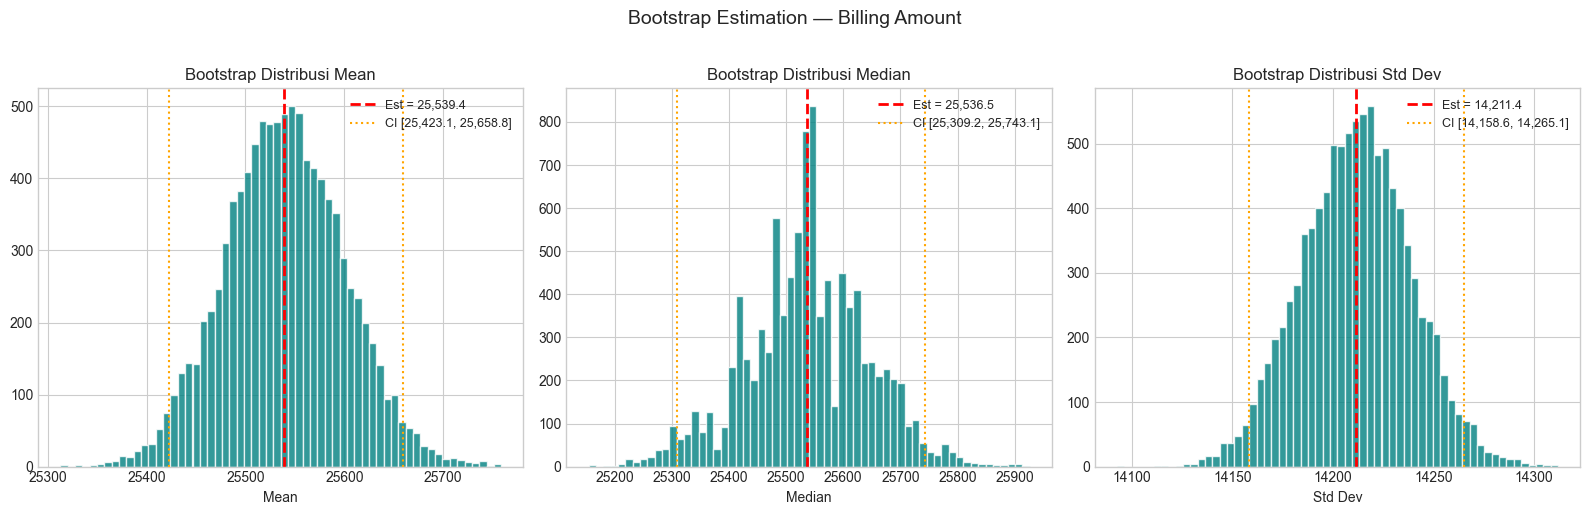

In [14]:
# Visualisasi distribusi bootstrap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, boot, ci, label in zip(
    axes,
    [boot_means, boot_medians, boot_stds],
    [ci_mean, ci_median, ci_std],
    ['Mean', 'Median', 'Std Dev']
):
    ax.hist(boot, bins=60, color='teal', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(boot), color='red',    ls='--', lw=2, label=f'Est = {np.mean(boot):,.1f}')
    ax.axvline(ci[0],         color='orange', ls=':',  lw=1.5, label=f'CI [{ci[0]:,.1f}, {ci[1]:,.1f}]')
    ax.axvline(ci[1],         color='orange', ls=':',  lw=1.5)
    ax.set_title(f'Bootstrap Distribusi {label}', fontsize=12)
    ax.set_xlabel(label)
    ax.legend(fontsize=9)

plt.suptitle('Bootstrap Estimation — Billing Amount', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Estimasi Bayesian

Estimasi Bayesian menggabungkan **prior belief** dengan **likelihood data** untuk menghasilkan **distribusi posterior**:

$$P(\theta | X) \propto P(X | \theta) \cdot P(\theta)$$

Untuk model Normal-Normal (conjugate prior):
- Prior: $\mu \sim N(\mu_0, \sigma_0^2)$
- Likelihood: $X | \mu \sim N(\mu, \sigma^2)$
- Posterior: $\mu | X \sim N(\mu_n, \sigma_n^2)$ (closed-form)

In [15]:
# ============================================================
# ESTIMASI BAYESIAN - Normal Conjugate Prior untuk Age
# ============================================================
data  = df['Age'].dropna().values
n     = len(data)
x_bar = np.mean(data)
sigma_known = np.std(data, ddof=1)   # asumsikan σ diketahui

# Prior hiperparameter (pengetahuan awal tentang usia rata-rata pasien)
mu_0    = 50.0    # prior mean
sigma_0 = 10.0    # prior std

# Update posterior (Normal conjugate)
sigma_n_sq = 1 / (n / sigma_known**2 + 1 / sigma_0**2)
mu_n       = sigma_n_sq * (n * x_bar / sigma_known**2 + mu_0 / sigma_0**2)
sigma_n    = np.sqrt(sigma_n_sq)

print('===== ESTIMASI BAYESIAN: Usia Pasien =====')
print(f'Data: n={n}, x̄={x_bar:.4f}, σ={sigma_known:.4f}')
print(f'Prior: μ_0={mu_0}, σ_0={sigma_0}')
print(f'Posterior: μ_n={mu_n:.6f}, σ_n={sigma_n:.6f}')

# Credible Interval (95% Highest Posterior Density)
ci_bayes = stats.norm.interval(0.95, loc=mu_n, scale=sigma_n)
print(f'95% Credible Interval: [{ci_bayes[0]:.4f}, {ci_bayes[1]:.4f}]')

===== ESTIMASI BAYESIAN: Usia Pasien =====
Data: n=55500, x̄=51.5395, σ=19.6025
Prior: μ_0=50.0, σ_0=10.0
Posterior: μ_n=51.539353, σ_n=0.083205
95% Credible Interval: [51.3763, 51.7024]


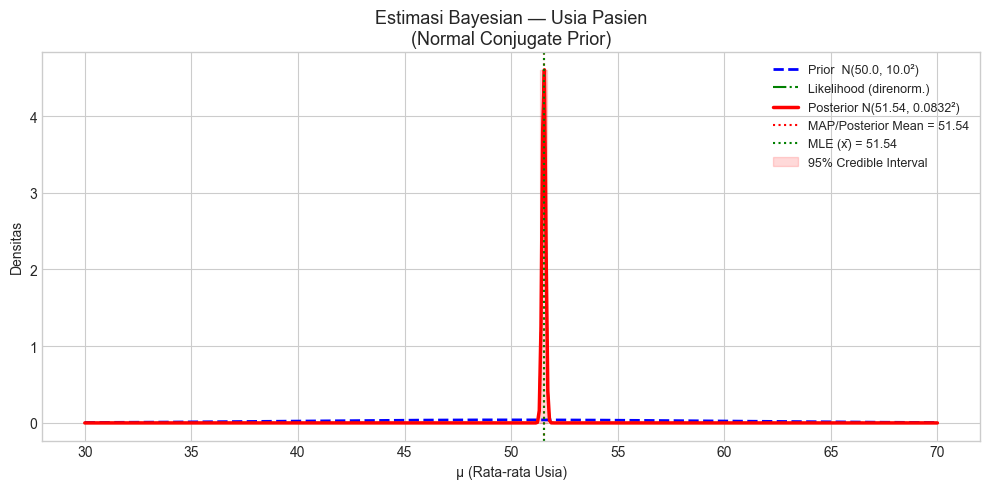

In [16]:
# Visualisasi Prior vs Posterior
theta = np.linspace(30, 70, 500)

prior_pdf     = stats.norm.pdf(theta, mu_0, sigma_0)
posterior_pdf = stats.norm.pdf(theta, mu_n, sigma_n)
# Likelihood (direnormalisasi untuk tampilan)
like = stats.norm.pdf(theta, x_bar, sigma_known / np.sqrt(n))
like_norm = like / like.max() * posterior_pdf.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(theta, prior_pdf,     'b--',  lw=2,   label=f'Prior  N({mu_0}, {sigma_0}²)')
ax.plot(theta, like_norm,     'g-.',  lw=1.5, label=f'Likelihood (direnorm.)')
ax.plot(theta, posterior_pdf, 'r-',   lw=2.5, label=f'Posterior N({mu_n:.2f}, {sigma_n:.4f}²)')
ax.axvline(mu_n,      color='red',    ls=':',  lw=1.5, label=f'MAP/Posterior Mean = {mu_n:.2f}')
ax.axvline(x_bar,     color='green',  ls=':',  lw=1.5, label=f'MLE (x̄) = {x_bar:.2f}')
ax.fill_betweenx([0, posterior_pdf.max()], ci_bayes[0], ci_bayes[1],
                 alpha=0.15, color='red', label='95% Credible Interval')
ax.set_title('Estimasi Bayesian — Usia Pasien\n(Normal Conjugate Prior)', fontsize=13)
ax.set_xlabel('μ (Rata-rata Usia)')
ax.set_ylabel('Densitas')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Estimasi Regresi Linier

Estimasi parameter regresi linier menggunakan **Ordinary Least Squares (OLS)**:

$$Y = \beta_0 + \beta_1 X_1 + ... + \beta_k X_k + \varepsilon$$

Estimator OLS: $\hat{\boldsymbol{\beta}} = (X^TX)^{-1}X^TY$

Kita akan mengestimasi **Billing Amount** berdasarkan **Usia, Lama Rawat Inap, dan Jenis Kelamin**.

In [17]:
# ============================================================
# REGRESI LINIER OLS
# ============================================================
from scipy import stats as sp

# Encode Gender
df['Gender_enc'] = LabelEncoder().fit_transform(df['Gender'])
df_reg = df[['Age', 'Length of Stay', 'Gender_enc', 'Billing Amount']].dropna()

X = df_reg[['Age', 'Length of Stay', 'Gender_enc']].values
y = df_reg['Billing Amount'].values
n, p = X.shape

# OLS manual (normal equation)
X_aug = np.column_stack([np.ones(n), X])  # tambah intercept
beta_hat = np.linalg.lstsq(X_aug, y, rcond=None)[0]

print('===== ESTIMASI OLS - Billing Amount =====')
labels = ['Intercept', 'Age', 'Length of Stay', 'Gender']
for lbl, b in zip(labels, beta_hat):
    print(f'  β_{lbl:<16} = {b:>12.4f}')

# Residual & R²
y_hat = X_aug @ beta_hat
resid = y - y_hat
SST   = np.sum((y - y.mean())**2)
SSR   = np.sum(resid**2)
R2    = 1 - SSR/SST
print(f'\nR² = {R2:.6f}')
print(f'RMSE = {np.sqrt(SSR/(n-p-1)):,.4f}')

===== ESTIMASI OLS - Billing Amount =====
  β_Intercept        =   25753.8154
  β_Age              =      -2.7378
  β_Length of Stay   =      -9.1726
  β_Gender           =     137.6021

R² = 0.000069
RMSE = 14,211.3472


In [18]:
# CI untuk koefisien regresi (t-test)
MSE   = SSR / (n - p - 1)
XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
se_beta = np.sqrt(MSE * np.diag(XtX_inv))
t_vals  = beta_hat / se_beta
p_vals  = 2 * (1 - stats.t.cdf(np.abs(t_vals), df=n-p-1))
t_crit  = stats.t.ppf(0.975, df=n-p-1)

print('===== CI 95% Koefisien Regresi =====')
print(f"{'Parameter':<16} {'Estimate':>10} {'SE':>10} {'t-stat':>10} {'p-value':>10} {'CI Lower':>12} {'CI Upper':>12}")
print('-' * 82)
for lbl, b, se, t, p in zip(labels, beta_hat, se_beta, t_vals, p_vals):
    print(f"{lbl:<16} {b:>10.4f} {se:>10.4f} {t:>10.4f} {p:>10.4f} {b-t_crit*se:>12.4f} {b+t_crit*se:>12.4f}")

===== CI 95% Koefisien Regresi =====
Parameter          Estimate         SE     t-stat    p-value     CI Lower     CI Upper
----------------------------------------------------------------------------------
Intercept        25753.8154   209.3376   123.0253     0.0000   25343.5123   26164.1185
Age                 -2.7378     3.0775    -0.8896     0.3737      -8.7697       3.2942
Length of Stay      -9.1726     6.9665    -1.3167     0.1880     -22.8269       4.4818
Gender             137.6021   120.6488     1.1405     0.2541     -98.8703     374.0746


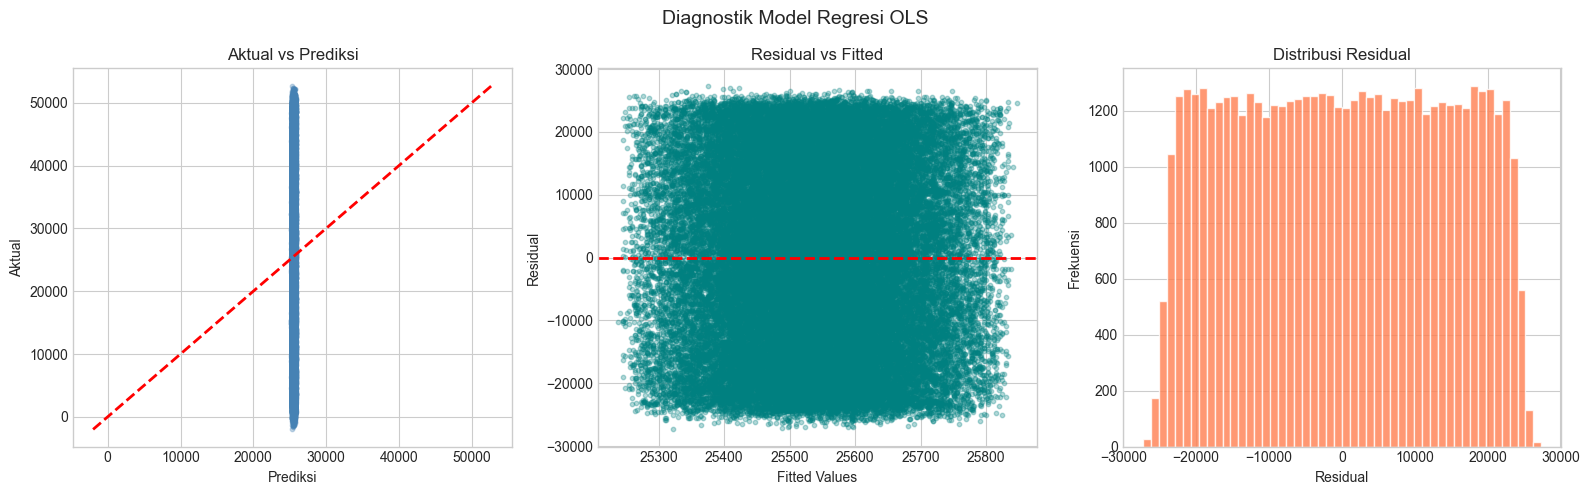

In [19]:
# Visualisasi Residual Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_hat, y, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
axes[0].set_title('Aktual vs Prediksi')

# Residual vs Fitted
axes[1].scatter(y_hat, resid, alpha=0.3, s=10, color='teal')
axes[1].axhline(0, color='red', lw=2, ls='--')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs Fitted')

# Histogram residual
axes[2].hist(resid, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frekuensi')
axes[2].set_title('Distribusi Residual')

plt.suptitle('Diagnostik Model Regresi OLS', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Estimasi Proporsi

Estimasi proporsi digunakan untuk variabel **kategorik** (misal: proporsi pasien dengan kondisi tertentu, tipe masuk darurat, dll.).

$$\hat{p} = \frac{x}{n}, \quad \text{CI: } \hat{p} \pm z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$$

In [20]:
# ============================================================
# ESTIMASI PROPORSI
# ============================================================
n_total = len(df)
z95 = stats.norm.ppf(0.975)

print('===== ESTIMASI PROPORSI (95% CI) =====')

# Proporsi per kategori
for col in ['Medical Condition', 'Admission Type', 'Test Results', 'Gender']:
    print(f'\n{col}:')
    vc = df[col].value_counts()
    for cat, cnt in vc.items():
        p_hat = cnt / n_total
        se_p  = np.sqrt(p_hat * (1 - p_hat) / n_total)
        ci_lo = max(0, p_hat - z95 * se_p)
        ci_hi = min(1, p_hat + z95 * se_p)
        print(f'  {str(cat):<20}: p̂={p_hat:.4f}  CI=[{ci_lo:.4f}, {ci_hi:.4f}]')

===== ESTIMASI PROPORSI (95% CI) =====

Medical Condition:
  Arthritis           : p̂=0.1677  CI=[0.1646, 0.1708]
  Diabetes            : p̂=0.1676  CI=[0.1645, 0.1707]
  Hypertension        : p̂=0.1666  CI=[0.1635, 0.1697]
  Obesity             : p̂=0.1663  CI=[0.1632, 0.1694]
  Cancer              : p̂=0.1663  CI=[0.1632, 0.1693]
  Asthma              : p̂=0.1655  CI=[0.1624, 0.1686]

Admission Type:
  Elective            : p̂=0.3361  CI=[0.3322, 0.3401]
  Urgent              : p̂=0.3347  CI=[0.3308, 0.3386]
  Emergency           : p̂=0.3292  CI=[0.3253, 0.3331]

Test Results:
  Abnormal            : p̂=0.3356  CI=[0.3317, 0.3396]
  Normal              : p̂=0.3336  CI=[0.3297, 0.3376]
  Inconclusive        : p̂=0.3307  CI=[0.3268, 0.3347]

Gender:
  Male                : p̂=0.5004  CI=[0.4963, 0.5046]
  Female              : p̂=0.4996  CI=[0.4954, 0.5037]


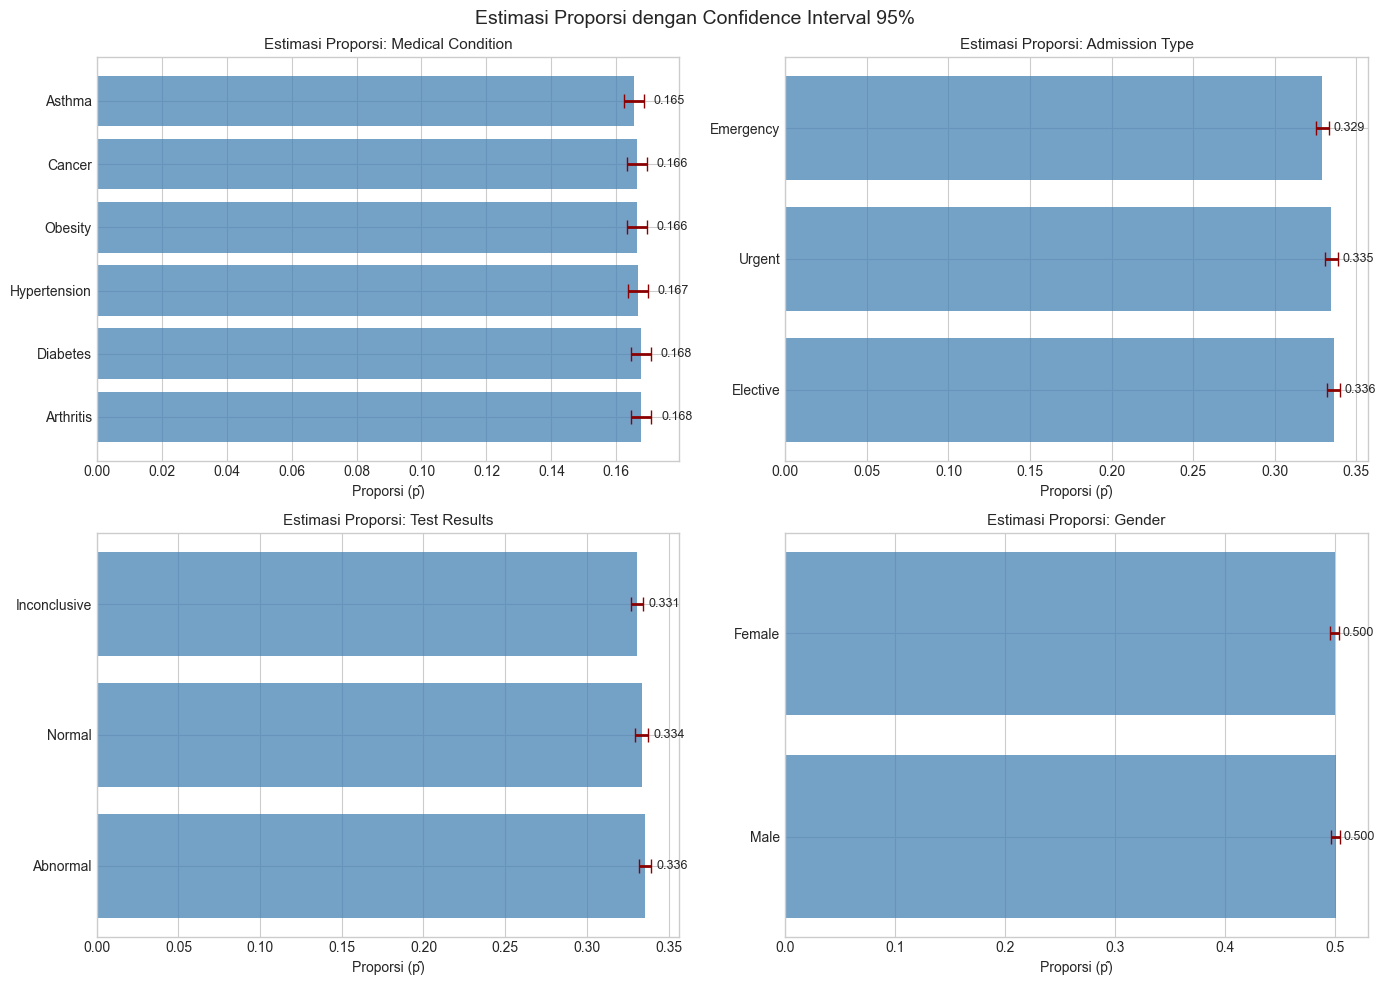

In [21]:
# Visualisasi estimasi proporsi dengan CI
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

z95 = stats.norm.ppf(0.975)
cols = ['Medical Condition', 'Admission Type', 'Test Results', 'Gender']

for ax, col in zip(axes, cols):
    vc = df[col].value_counts()
    cats = vc.index.tolist()
    p_hats = vc.values / n_total
    ses    = np.sqrt(p_hats * (1 - p_hats) / n_total)

    ax.barh(cats, p_hats, xerr=z95*ses, color='steelblue', alpha=0.75,
            error_kw={'capsize': 5, 'elinewidth': 2, 'ecolor': 'darkred'})
    ax.set_title(f'Estimasi Proporsi: {col}', fontsize=11)
    ax.set_xlabel('Proporsi (p̂)')
    for i, (p, s) in enumerate(zip(p_hats, ses)):
        ax.text(p + z95*s + 0.003, i, f'{p:.3f}', va='center', fontsize=9)

plt.suptitle('Estimasi Proporsi dengan Confidence Interval 95%', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Ringkasan Perbandingan Semua Metode Estimasi

In [22]:
data = df['Billing Amount'].dropna().values
n    = len(data)

# MLE
mu_mle, sigma_mle = stats.norm.fit(data)

# Metode Momen
mu_mm    = np.mean(data)
sigma_mm = np.sqrt(np.mean(data**2) - np.mean(data)**2)

# Bootstrap
np.random.seed(42)
boot_m = [np.mean(np.random.choice(data, n, replace=True)) for _ in range(5000)]
boot_mu = np.mean(boot_m)
boot_ci = np.percentile(boot_m, [2.5, 97.5])

# CI Klasik
classic_ci = stats.t.interval(0.95, df=n-1, loc=np.mean(data), scale=stats.sem(data))

print('=' * 70)
print('       RINGKASAN ESTIMASI μ (Billing Amount)')
print('=' * 70)
print(f"{'Metode':<25} {'Estimasi μ':>15} {'CI/Interval':>25}")
print('-' * 70)
print(f"{'Estimasi Titik (Mean)':<25} {np.mean(data):>15,.2f} {'—':>25}")
print(f"{'CI t-distribution 95%':<25} {np.mean(data):>15,.2f} {f'[{classic_ci[0]:,.2f}, {classic_ci[1]:,.2f}]':>25}")
print(f"{'MLE (Normal)':<25} {mu_mle:>15,.2f} {'—':>25}")
print(f"{'Metode Momen':<25} {mu_mm:>15,.2f} {'—':>25}")
print(f"{'Bootstrap (B=5000)':<25} {boot_mu:>15,.2f} {f'[{boot_ci[0]:,.2f}, {boot_ci[1]:,.2f}]':>25}")
print('=' * 70)
print('\n📌 Catatan: Untuk Billing Amount, semua metode konvergen ke nilai μ yang sama.')
print('   Perbedaan antar metode lebih terlihat pada data kecil atau distribusi tidak normal.')

       RINGKASAN ESTIMASI μ (Billing Amount)
Metode                         Estimasi μ               CI/Interval
----------------------------------------------------------------------
Estimasi Titik (Mean)           25,539.32                         —
CI t-distribution 95%           25,539.32    [25,421.08, 25,657.55]
MLE (Normal)                    25,539.32                         —
Metode Momen                    25,539.32                         —
Bootstrap (B=5000)              25,540.46    [25,425.55, 25,660.58]

📌 Catatan: Untuk Billing Amount, semua metode konvergen ke nilai μ yang sama.
   Perbedaan antar metode lebih terlihat pada data kecil atau distribusi tidak normal.
